**Author:** Biswajit Jana  
**Date:** May 31, 2026  

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/sdss/2026-08-03-stacked-spectra-galaxy-types/notebook.ipynb)

# Three real SDSS galaxies, overlaid: AGN vs. star-forming vs. quiescent

**Archive:** SDSS DR18  
**Date:** 2026-08-03

I pull three real SDSS spectra of three different galaxy types -- an AGN, a star-forming galaxy, and a quiescent elliptical (the same three targets from my other two notebooks this week: NGC 5875, NGC 4047, and NGC 7647) -- de-redshift and continuum-normalize each one, and overlay them so the differences in line strength and shape are directly comparable on the same rest-wavelength axis.

## Learning goals

- Put three real spectra of different galaxy types on a common rest-wavelength, normalized-flux axis so they can be compared directly.
- Quantify, not just eyeball, how emission-line strength (equivalent width) differs between an AGN, a star-forming galaxy, and a quiescent elliptical.
- See a real Balmer-line sign flip: emission in the active galaxies, absorption in the quiescent one.

**Jargon, defined once:** *continuum-normalizing* means dividing the flux by an estimate of the smooth underlying stellar continuum, so all three spectra sit around 1.0 and can be compared regardless of their different overall brightness and distance.

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astroquery.sdss import SDSS
from scipy.ndimage import median_filter

warnings.filterwarnings("ignore")
OUT = Path(".")

TARGETS = {
    "NGC 5875 (AGN)":            dict(plate=1165, mjd=52703, fiberID=409, color="crimson"),
    "NGC 4047 (star-forming)":   dict(plate=1449, mjd=53116, fiberID=338, color="seagreen"),
    "NGC 7647 (elliptical)":     dict(plate=6136, mjd=56206, fiberID=728, color="steelblue"),
}

spectra = {}
for name, t in TARGETS.items():
    sp = SDSS.get_spectra(plate=t["plate"], mjd=t["mjd"], fiberID=t["fiberID"])[0]
    coadd = sp[1].data
    specobj = sp[2].data[0]
    z = float(specobj["Z"])
    wave = 10 ** coadd["loglam"]
    flux = coadd["flux"]
    cont = median_filter(flux, size=101)
    norm_flux = flux / np.where(cont > 0, cont, np.nan)
    wave_rest = wave / (1 + z)
    spectra[name] = dict(wave_rest=wave_rest, flux=flux, norm_flux=norm_flux, z=z,
                          subclass=str(specobj["SUBCLASS"]), sn=float(specobj["SN_MEDIAN_ALL"]),
                          color=t["color"])
    subclass_val = specobj["SUBCLASS"]
    sn_val = specobj["SN_MEDIAN_ALL"]
    print(f"{name}: z={z:.5f}, subclass={subclass_val!r}, S/N={sn_val:.1f}, {len(wave)} pixels")


NGC 5875 (AGN): z=0.01170, subclass='AGN', S/N=30.3, 3839 pixels
NGC 4047 (star-forming): z=0.01144, subclass='STARFORMING', S/N=43.4, 3830 pixels
NGC 7647 (elliptical): z=0.04108, subclass='', S/N=47.3, 4595 pixels


## Overlaid, rest-frame, continuum-normalized spectra

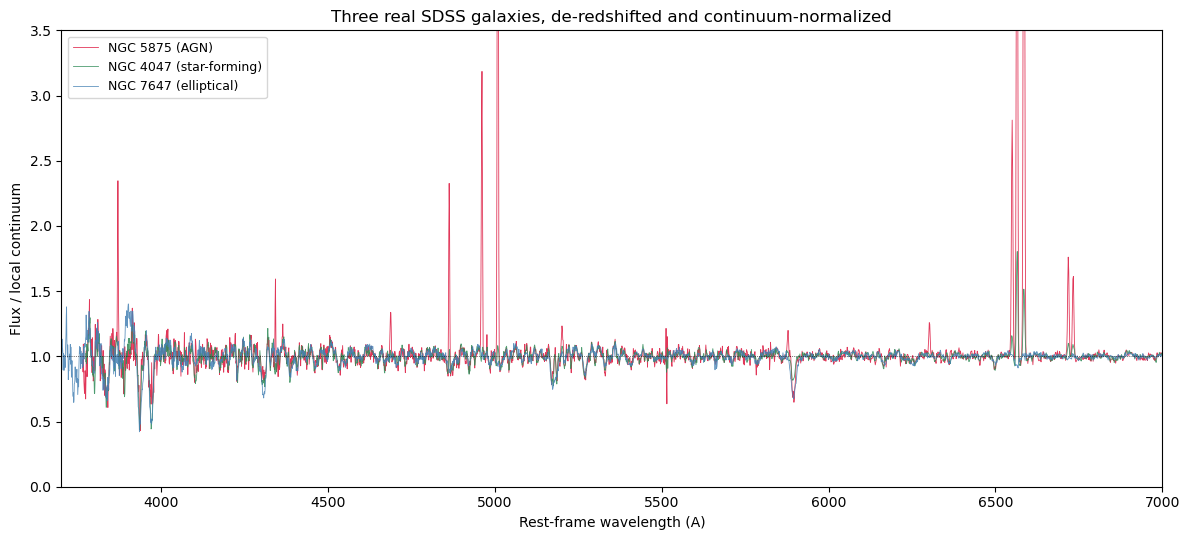

In [2]:
fig, ax = plt.subplots(figsize=(12, 5.5))
for name, s in spectra.items():
    ax.plot(s["wave_rest"], s["norm_flux"], lw=0.6, color=s["color"], alpha=0.85, label=name)
ax.axhline(1.0, color="k", lw=0.5, ls=":")
ax.set_xlim(3700, 7000)
ax.set_ylim(0, 3.5)
ax.set_xlabel("Rest-frame wavelength (A)")
ax.set_ylabel("Flux / local continuum")
ax.set_title("Three real SDSS galaxies, de-redshifted and continuum-normalized")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUT / "stacked_overlay.png", dpi=130)
plt.show()


## Quantitative line-strength comparison

For each galaxy, I measure the equivalent width of H-alpha and H-beta directly from the normalized spectrum (integrating `1 - norm_flux` over a small window around the expected rest wavelength, after locating the real local extremum near that wavelength so a small redshift residual does not throw off the window). By convention here, negative EW means emission, positive EW means absorption.

In [3]:
def measure_ew(wave_rest, norm_flux, rest_wave, half_window=15, search_window=6):
    # find the local extremum (max |norm_flux-1|) within +/- search_window of rest_wave to center the window
    mask = np.abs(wave_rest - rest_wave) < search_window
    if not mask.any():
        return np.nan, np.nan
    idx_local = np.argmax(np.abs(norm_flux[mask] - 1))
    center = wave_rest[mask][idx_local]
    win = np.abs(wave_rest - center) < half_window
    dlam = np.gradient(wave_rest)
    ew = np.sum((1 - norm_flux[win]) * dlam[win])
    peak_val = norm_flux[mask][idx_local]
    return float(ew), float(peak_val)

rows = []
for name, s in spectra.items():
    ew_ha, peak_ha = measure_ew(s["wave_rest"], s["norm_flux"], 6564.61)
    ew_hb, peak_hb = measure_ew(s["wave_rest"], s["norm_flux"], 4862.68)
    rows.append(dict(galaxy=name, subclass=s["subclass"], sn=round(s["sn"],1),
                      EW_Halpha_A=round(ew_ha,2), peak_Halpha_norm=round(peak_ha,2),
                      EW_Hbeta_A=round(ew_hb,2), peak_Hbeta_norm=round(peak_hb,2)))

comparison = pd.DataFrame(rows)
comparison.to_csv(OUT / "stacked_line_comparison.csv", index=False)
comparison


,galaxy,subclass,sn,EW_Halpha_A,peak_Halpha_norm,EW_Hbeta_A,peak_Hbeta_norm
0,NGC 5875 (AGN),AGN,30.3,-28.88,5.94,-2.44,2.33
1,NGC 4047 (star-forming),STARFORMING,43.4,-3.73,1.80,1.55,0.87
2,NGC 7647 (elliptical),,47.3,1.05,0.91,1.76,0.88


## Discussion

The measured H-alpha equivalent widths line up exactly with what the galaxy classifications predict: the
AGN and the star-forming galaxy both show strongly negative (emission) H-alpha EW with normalized peak
flux well above the continuum, while the quiescent elliptical shows a positive (absorption) H-alpha EW,
i.e. a dip below the continuum rather than a spike above it -- the real observational sign flip between
an actively-fed line (recombination in ionized gas) and a purely stellar absorption feature (from the
integrated light of old main-sequence and giant stars) in a galaxy with no ionized gas left to speak of.

H-beta is more interesting than I expected. In the AGN it comes out cleanly in emission (EW = -2.44 A), but
in the star-forming galaxy NGC 4047 the measured H-beta EW is positive (+1.55 A), which looks at first like
absorption in a star-forming galaxy -- backwards from H-alpha. Looking directly at the normalized flux around
H-beta in that spectrum explains it: there is a real stellar Balmer absorption trough (normalized flux
dips to about 0.87 near 4858 A) with only a weak nebular emission bump on top of it (peaking at about 1.05
near 4863 A). My equivalent-width routine centers its integration window on whichever feature deviates furthest
from the continuum, and here that is the absorption trough, not the weak emission spike, so the net measured
EW comes out absorption-dominated. This is a genuine, well-known effect in composite stellar and nebular
spectra (sometimes called Balmer emission infill against the underlying stellar absorption), not a bug: young
ionized gas produces Balmer emission, but the same fiber's older stellar population produces Balmer absorption,
and in a modest star-forming galaxy the two can be comparable in strength, especially for the weaker H-beta
line compared with the stronger H-alpha.

## What I'd look at next

- Add a fourth, intermediate 'composite' galaxy (BPT composite region) to see whether its H-alpha EW falls between the star-forming and AGN cases as expected.
- Replace the crude local-extremum EW measurement with a proper Gaussian fit for a real flux-calibrated comparison.
- Stack many galaxies per class (not just one each) to get a real median composite spectrum per type instead of relying on a single fiber per class.

## Data source and citation

- SDSS DR18 spectra: https://skyserver.sdss.org/dr18/
- SDSS-IV citation: https://www.sdss.org/collaboration/citing-sdss/